# Data and libraries

In [363]:
# standard packaging

import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(color_codes=True, rc={'figure.figsize':(10,8)})

from IPython.display import HTML #Youtube embed

In [364]:
# load the dataset from GitHub - original source

data = pd.read_csv("data/bcn_noise_class_ml_reduced.csv")

# Data Inspection

In [365]:
#inspect data
data.info()
print(data)

<class 'pandas.DataFrame'>
RangeIndex: 12854 entries, 0 to 12853
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   road_id              12854 non-null  str    
 1   noise_day            12854 non-null  int64  
 2   noise_evening        12854 non-null  int64  
 3   noise_night          12854 non-null  int64  
 4   road_category        12854 non-null  int64  
 5   dist_to_trunk        12854 non-null  float64
 6   dist_to_primary      12854 non-null  float64
 7   dist_to_secondary    12854 non-null  float64
 8   dist_to_tertiary     12854 non-null  float64
 9   dist_to_residential  12854 non-null  float64
 10  signals              12854 non-null  float64
 11  transport            12854 non-null  float64
 12  pois                 12854 non-null  float64
 13  width                12854 non-null  float64
 14  betweenness          12854 non-null  float64
 15  closeness_global     12854 non-null  float64
 1

In [366]:
data_clean = data.dropna(how = "any")
data_clean.info()
data_clean.reset_index(inplace=True, drop = True)
data_clean

<class 'pandas.DataFrame'>
RangeIndex: 12854 entries, 0 to 12853
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   road_id              12854 non-null  str    
 1   noise_day            12854 non-null  int64  
 2   noise_evening        12854 non-null  int64  
 3   noise_night          12854 non-null  int64  
 4   road_category        12854 non-null  int64  
 5   dist_to_trunk        12854 non-null  float64
 6   dist_to_primary      12854 non-null  float64
 7   dist_to_secondary    12854 non-null  float64
 8   dist_to_tertiary     12854 non-null  float64
 9   dist_to_residential  12854 non-null  float64
 10  signals              12854 non-null  float64
 11  transport            12854 non-null  float64
 12  pois                 12854 non-null  float64
 13  width                12854 non-null  float64
 14  betweenness          12854 non-null  float64
 15  closeness_global     12854 non-null  float64
 1

,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,signals,transport,pois,width,betweenness,closeness_global,closeness_400,straightness
0,13859746870_13859746860_0,2,2,2,5,213.093233,512.208689,1110.052349,188.355179,0.000000,0.053298,0.000000,0.106597,50.000000,0.000039,0.000187,0.000017,0.807756
1,13798851565_8465472214_0,2,2,1,5,549.529452,1655.791584,2110.530434,351.777378,0.000000,0.000000,0.014274,0.000000,20.006115,0.000224,0.000109,0.000004,0.741368
2,4538123419_13734642240_0,3,3,3,3,904.118521,947.154817,0.000000,167.026629,0.000000,0.167307,0.000000,0.295484,50.000000,0.010452,0.000182,0.000018,0.831327
3,13845167536_847716886_0,2,2,1,5,1877.603526,419.287598,661.587375,10.597441,0.000000,0.000000,0.012453,0.002491,16.759462,0.004427,0.000215,0.000009,0.757172
4,13845167536_253790691_0,2,2,2,5,1872.177506,614.353897,967.746460,0.000000,0.000000,0.000000,0.053513,0.000000,50.000000,0.003735,0.000208,0.000006,0.736805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12849,8930700699_9446738721_0,2,2,2,5,1193.777243,3718.930278,504.636951,2.621987,0.000000,0.000000,0.000000,0.000000,50.000000,0.000223,0.000092,0.000033,0.808845
12850,8930700699_9446689099_0,2,2,2,5,1192.427548,3718.930278,504.636951,5.401547,0.000000,0.000000,0.000000,0.000000,50.000000,0.000008,0.000092,0.000032,0.808437
12851,559052401_3358594835_0,4,3,3,4,2094.223791,1392.526259,0.000000,0.000000,85.200353,0.069739,0.008717,0.008717,34.151619,0.002093,0.000172,0.000025,0.847426
12852,9446738720_553047568_0,2,2,2,5,1213.043969,3731.356864,511.506989,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.001329,0.000093,0.000035,0.812192


### scaling

In [367]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [368]:
X = data_clean.drop(columns=['road_id','noise_day','noise_evening', 'noise_night']) 
X_scaled = scaler.fit_transform(X)
X.head()

,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,signals,transport,pois,width,betweenness,closeness_global,closeness_400,straightness
0,5,213.093233,512.208689,1110.052349,188.355179,0.0,0.053298,0.000000,0.106597,50.000000,0.000039,0.000187,0.000017,0.807756
1,5,549.529452,1655.791584,2110.530434,351.777378,0.0,0.000000,0.014274,0.000000,20.006115,0.000224,0.000109,0.000004,0.741368
2,3,904.118521,947.154817,0.000000,167.026629,0.0,0.167307,0.000000,0.295484,50.000000,0.010452,0.000182,0.000018,0.831327
3,5,1877.603526,419.287598,661.587375,10.597441,0.0,0.000000,0.012453,0.002491,16.759462,0.004427,0.000215,0.000009,0.757172
4,5,1872.177506,614.353897,967.746460,0.000000,0.0,0.000000,0.053513,0.000000,50.000000,0.003735,0.000208,0.000006,0.736805


In [369]:
import numpy as np
y = np.asarray(data_clean["noise_day"])
y

array([2, 2, 3, ..., 4, 2, 2], shape=(12854,))

### splitting

In [370]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, data_train, data_test = train_test_split(X_scaled, y, data, test_size = 0.2, random_state = 42)

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)


(10283, 14)
(10283,)
(2571, 14)


# Train model

In [371]:
# Import K-fold crossvalidation
from sklearn.model_selection import cross_val_score

# Import Classification Report for later evaluatoion of performance
from sklearn.metrics import classification_report

## Logistic Regression

In [372]:
# Import and instantiate the model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=2000)

# K-fold cross-validation (splitting the 80% into 5 chunks, using 4 to train and 1 to evaluate)
scores = cross_val_score(model, X_train, y_train, cv = 5)
print(scores)



[0.6110841  0.62323772 0.60330579 0.61819066 0.60749027]


In [373]:
# Model training
model.fit(X_train, y_train)

# Model performance on the test-set
print(model.score(X_test, y_test))

0.6005445352003111


In [374]:
y_pred = model.predict(X_test)


(<Figure size 1000x800 with 2 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

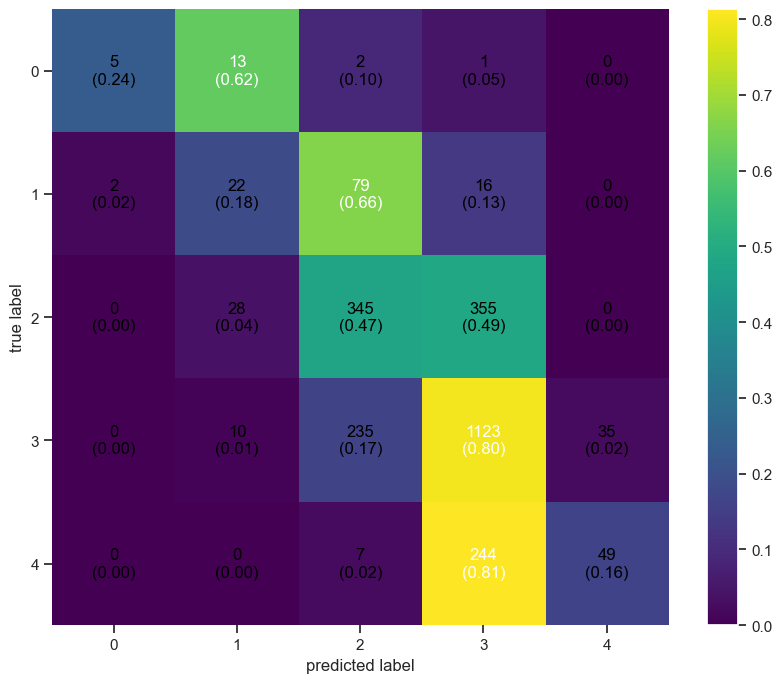

In [375]:
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix

confmatrix = confusion_matrix(y_test,y_pred)
plot_confusion_matrix(conf_mat=confmatrix,colorbar=True,show_absolute=True,show_normed=True,hide_spines = True,cmap='viridis')

## XG boost

In [376]:
import xgboost as xgb

model = xgb.XGBClassifier(
    )

scores = cross_val_score(model, X_train, y_train, cv = 5)
print(scores)

model.fit(X_train, y_train)
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

xgb.XGBClassifier(eval_metric="mlogloss")  # multiclass
xgb.XGBClassifier(eval_metric="logloss")   # binary

[0.73262032 0.72532815 0.73359261 0.72422179 0.72470817]
0.9679081979966936
0.7390120575651498


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [377]:
# Performance evaluation using the classification_report
y_pred = model.predict(X_test) # predict from the testset


In [378]:
data_test["y_pred"]= y_pred
data_test["y_truth"]= y_test
data_test["y_diff"]= y_pred - y_test

(<Figure size 1000x800 with 2 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

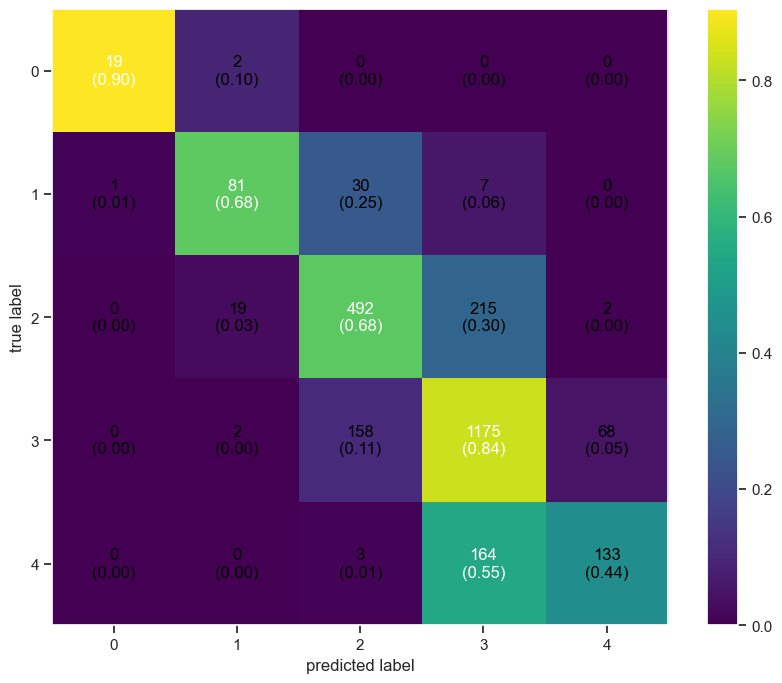

In [379]:
# calculate the confusion matrix
confmatrix = confusion_matrix(y_test,y_pred)

# Let's plot
plot_confusion_matrix(conf_mat=confmatrix,
                                colorbar=True,
                                show_absolute=True,
                                show_normed=True,
                                cmap='viridis',)

In [380]:
osm_roads = gpd.read_file("data/bcn_osmnx_edges.gpkg")
merged_gdf = osm_roads.merge(data_test, left_on='segment_id', right_on='road_id', how='left')

<Axes: >

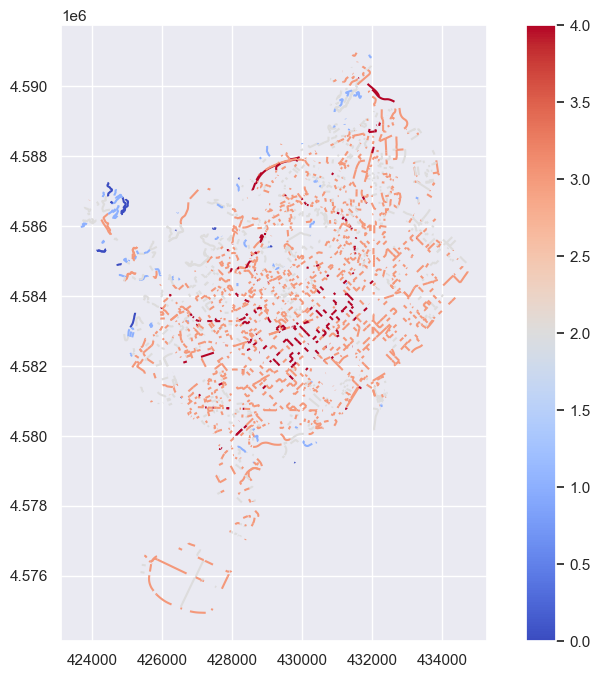

In [381]:
merged_gdf.plot(
    column='y_pred', 
    cmap='coolwarm', 
    legend=True
)


## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [383]:
model = RandomForestClassifier(
    random_state=42,
    max_depth=None,         
    min_samples_leaf=1,    
    min_samples_split=2,   
)

scores = cross_val_score(model, X_train, y_train, cv = 5)
print(scores)

model.fit(X_train, y_train)
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

xgb.XGBClassifier(eval_metric="mlogloss")  # multiclass
xgb.XGBClassifier(eval_metric="logloss")   # binary

[0.73699562 0.72532815 0.7301896  0.73978599 0.71984436]
0.9984440338422639
0.7460132244262933


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [384]:
# Performance evaluation using the classification_report
y_pred = model.predict(X_test) # predict from the testset

(<Figure size 1000x800 with 2 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

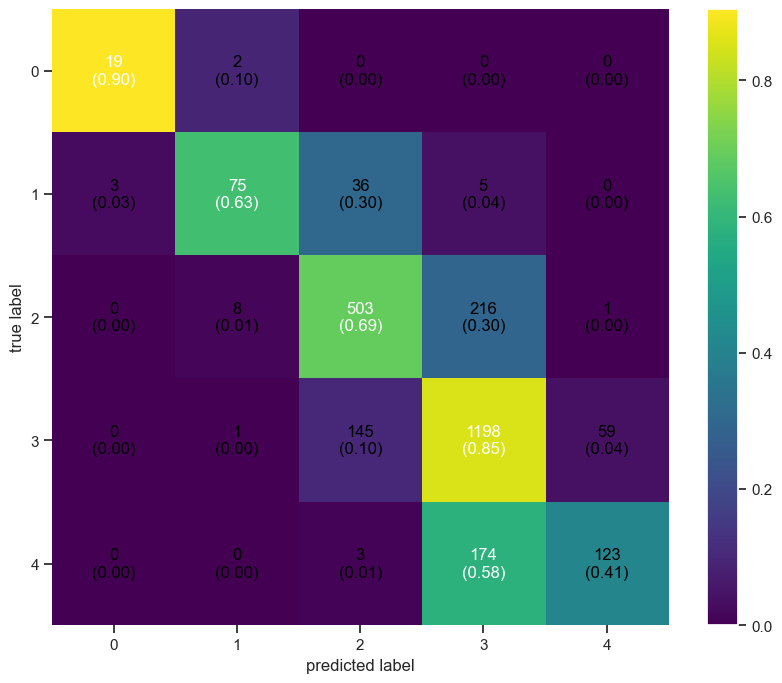

In [ ]:
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix

confmatrix = confusion_matrix(y_test,y_pred)
plot_confusion_matrix(conf_mat=confmatrix,
                      colorbar=True,
                      show_absolute=True,
                      show_normed=True,
                      hide_spines = True,
                      cmap='viridis')

In [ ]:
fig, ax = plot_confusion_matrix(conf_mat=confmatrix,
                                colorbar=True,
                                show_absolute=True,
                                show_normed=True,
                                hide_spines=True,
                                cmap='viridis')

for text in ax.texts:
    text.set_color('black' if text.get_color() == 'white' else 'white')

plt.show()

In [386]:
osm_roads = gpd.read_file("data/bcn_osmnx_edges.gpkg")
merged_gdf = osm_roads.merge(data_test, left_on='segment_id', right_on='road_id', how='left')

In [387]:
m = merged_gdf.to_crs(epsg=4326).explore(
    column='y_diff',
    cmap='RdBu',
    tiles='CartoDB positron',
    tooltip=['road_id', 'y_diff', 'y_pred', 'y_truth', 'highway'],
    legend=True,
)
m.save("map_y_diff.html")

import webbrowser, os
webbrowser.open('file://' + os.path.realpath("map_y_diff.html"))

True

In [388]:
merged_gdf = merged_gdf[merged_gdf['y_diff'] != 4]